# The

In [1]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

## Grab data from csv, import to dataframe, split into features and labels

In [2]:
df = pd.read_csv("creditcard.csv")

X = df.loc[:, df.columns != "Class"]
y = df["Class"]

X, y


(            Time         V1         V2        V3        V4        V5  \
 0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
 1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
 2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
 3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
 4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
 ...          ...        ...        ...       ...       ...       ...   
 284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
 284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
 284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
 284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
 284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   
 
               V6        V7        V8        V9  ...       V20       V21  \
 0       0.462388  0.239599  0.098698  0.36378

## Remove bad values and check for empty values

In [3]:
bad = X.isna().any(axis=1)
X = X[~bad]
y = y[~bad]

na_x = X.isna().sum(axis=0)
na_y = y.isna().sum(axis=0)

print(na_x, na_y)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
dtype: int64 0


## TUrning them into np arrays

In [4]:

X = X.values.astype('float32')
y = y.values.astype('int64')

## Convert to Torch tensors

In [5]:
# lster on

## Convert to tensor dataset, train test split

In [6]:
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

#tryna avoid data leakage
avg = X_train.mean(axis=0, keepdims=True)
stdev = X_train.std(axis=0, keepdims=True)

X_train = (X_train - avg) / stdev
X_test = (X_test - avg) / stdev


X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).long()
X_test = torch.tensor(X_test).float()
y_test = torch.tensor(y_test).long()

train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

## Model Architecture

In [7]:
linear_model = torch.nn.Sequential(
    torch.nn.Linear(30, 256),
    torch.nn.GELU(),
    torch.nn.Linear(256, 64),
    torch.nn.GELU(),
    torch.nn.Linear(64, 2),
)

loss_fn = torch.nn.CrossEntropyLoss()
lr = 3e-4
opt = torch.optim.AdamW(linear_model.parameters(), lr=lr)

In [8]:
for epoch in range(10):
    for batch in tqdm(train_loader, desc=f'Epoch: {epoch}'):
        X_batch, y_batch = batch
        pred = linear_model(X_batch)
        loss = loss_fn(pred, y_batch)
        opt.zero_grad()
        loss.backward()
        opt.step()

Epoch: 9: 100%|██████████| 3561/3561 [00:02<00:00, 1325.69it/s]


Predicting...: 100%|██████████| 891/891 [00:00<00:00, 4509.70it/s]


Accuracy: 0.9993153330290369


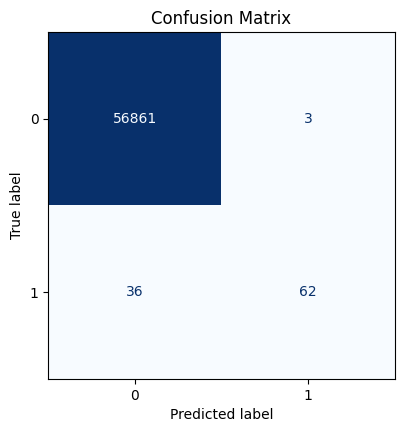

In [9]:
linear_model.eval()

correct = 0
total = 0

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc="Predicting..."):
        pred = linear_model(X_batch)
        predicted_labels = pred.argmax(dim=1)

        y_true.append(y_batch.cpu())
        y_pred.append(predicted_labels.cpu())

        correct += (predicted_labels == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print(f"Accuracy: {accuracy}")

# Confusion matrix (sklearn)
y_true = torch.cat(y_true).numpy()
y_pred = torch.cat(y_pred).numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix")
plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn) if (tp + fn) else 0.0
precision = tp / (tp + fp) if (tp + fp) else 0.0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0
total_fraud = y_test.sum()

print(
    f"total fraud: {total_fraud}\n"
    f"true positives: {tp}\n"
    f"true negatives: {tn}\n"
    f"false positives: {fp}\n"
    f"false negatives: {fn}\n"
    f"precision: {precision}\n"
    f"recall: {recall}\n"
    f"f1: {f1}\n"
    f"% of fraudulent transactions in test set classified incorrectly: {fn / total_fraud}"
)

total fraud: 98
true positives: 62
true negatives: 56861
false positives: 3
false negatives: 36
precision: 0.9538461538461539
recall: 0.6326530612244898
f1: 0.7607361963190183
% of fraudulent transactions in test set classified incorrectly: 0.36734694242477417
